In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("SuperStoreOrders.csv")

df.head()

C:\Users\user 2\AppData\Local\Temp\ipykernel_21628\327767177.py:1: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,12,13,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("SuperStoreOrders.csv")


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit/loss
0,AG-2011-2040,40544.0,40549.0,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408.0,2.0,0.0,106.140,35.46,Medium,2011.0,profit
1,IN-2011-47883,40544.0,40551.0,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120.0,3.0,0.1,36.036,9.72,Medium,2011.0,profit
2,HU-2011-1220,40544.0,40548.0,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66.0,4.0,0.0,29.640,8.17,High,2011.0,profit
3,IT-2011-3647632,40544.0,40548.0,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45.0,3.0,0.5,-26.055,4.82,High,2011.0,loss
4,IN-2011-47883,40544.0,40551.0,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5.0,0.1,37.770,4.70,Medium,2011.0,profit


In [11]:
print("Shape: ",df.shape)

Shape:  (1048575, 22)


In [12]:
print("Information: ",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   order_id        51290 non-null    object 
 1   order_date      51290 non-null    float64
 2   ship_date       51290 non-null    float64
 3   ship_mode       51290 non-null    object 
 4   customer_name   51290 non-null    object 
 5   segment         51290 non-null    object 
 6   state           51290 non-null    object 
 7   country         51290 non-null    object 
 8   market          51290 non-null    object 
 9   region          51290 non-null    object 
 10  product_id      51290 non-null    object 
 11  category        51290 non-null    object 
 12  sub_category    51290 non-null    object 
 13  product_name    51290 non-null    object 
 14  sales           51290 non-null    float64
 15  quantity        51290 non-null    float64
 16  discount        51290 non-null    fl

In [13]:
print("Describe: ",df.describe())

Describe:           order_date     ship_date         sales      quantity      discount  \
count  51290.000000  51290.000000  51290.000000  51290.000000  51290.000000   
mean   41405.893624  41409.862995    246.498440      3.476545      0.142908   
std      412.557888    412.558057    487.567175      2.278766      0.212280   
min    40544.000000  40546.000000      0.000000      1.000000      0.000000   
25%    41079.000000  41083.000000     31.000000      2.000000      0.000000   
50%    41463.000000  41467.000000     85.000000      3.000000      0.000000   
75%    41781.000000  41785.000000    251.000000      5.000000      0.200000   
max    42004.000000  42011.000000  22638.000000     14.000000      0.850000   

             profit  shipping_cost          year  
count  51290.000000   51290.000000  51290.000000  
mean      28.641740      26.375915   2012.777208  
std      174.424113      57.296804      1.098931  
min    -6599.978000       0.000000   2011.000000  
25%        0.000000   

In [27]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [14]:
print("Number of NULL values : " , df.isnull().sum())

Number of NULL values :  order_id          997285
order_date        997285
ship_date         997285
ship_mode         997285
customer_name     997285
segment           997285
state             997285
country           997285
market            997285
region            997285
product_id        997285
category          997285
sub_category      997285
product_name      997285
sales             997285
quantity          997285
discount          997285
profit            997285
shipping_cost     997285
order_priority    997285
year              997285
profit/loss            0
dtype: int64


In [16]:
df = df.dropna()

In [17]:
print("new shape : ", df.shape)

new shape :  (51290, 22)


In [24]:
total_sales = df["sales"].sum()

print(total_sales)

12642905.0


In [28]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [29]:
total_sales = df['sales'].sum()

print(f"Total Sales: {total_sales:,.2f}")

Total Sales: 12,642,905.00


In [30]:
total_profit = df['profit'].sum()

print(f"Total Profit: {total_profit:,.2f}")

Total Profit: 1,469,034.82


In [31]:
total_orders = df['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 25035


In [32]:
total_customers = df['customer_name'].nunique()

print("Total Customers:", total_customers)

Total Customers: 795


In [33]:
category_sales = (
    df.groupby('category')['sales']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

category
Technology         4744691.0
Furniture          4110884.0
Office Supplies    3787330.0
Name: sales, dtype: float64


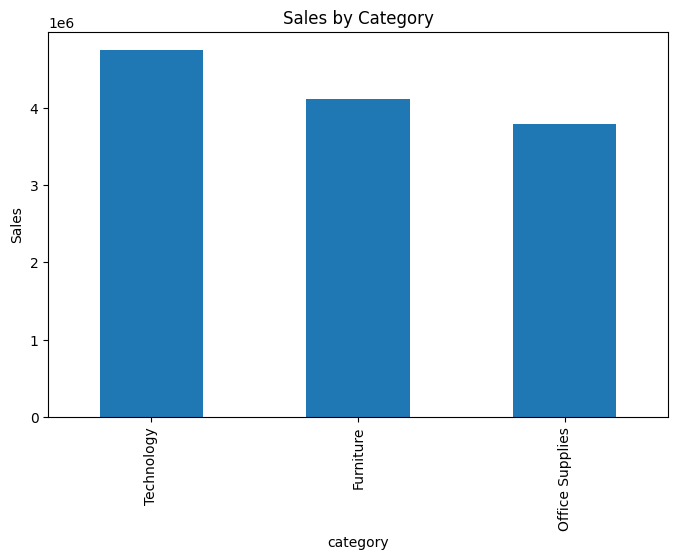

In [34]:
category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

In [35]:
profit_category = (
    df.groupby('category')['profit']
      .sum()
      .sort_values(ascending=False)
)

profit_category

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

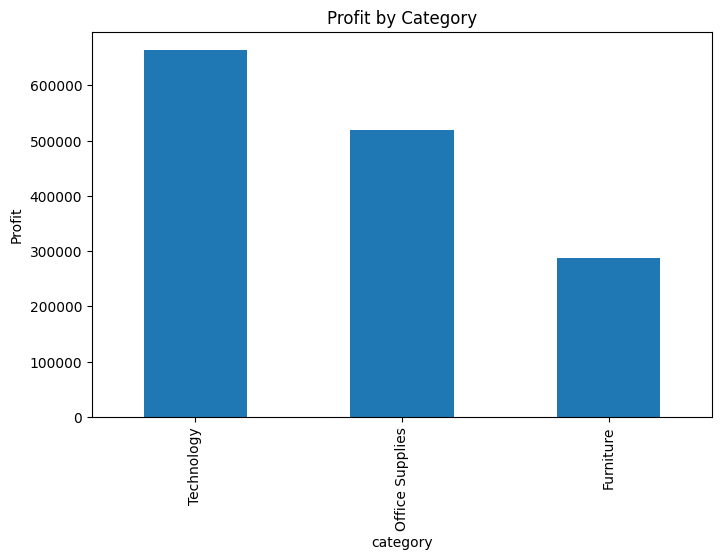

In [36]:
profit_category.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

In [37]:
region_sales = (
    df.groupby('region')['sales']
      .sum()
      .sort_values(ascending=False)
)

region_sales

region
Central           2822399.0
South             1600960.0
North             1248192.0
Oceania           1100207.0
Southeast Asia     884438.0
North Asia         848349.0
EMEA               806184.0
Africa             783776.0
Central Asia       752839.0
West               725514.0
East               678834.0
Caribbean          324281.0
Canada              66932.0
Name: sales, dtype: float64

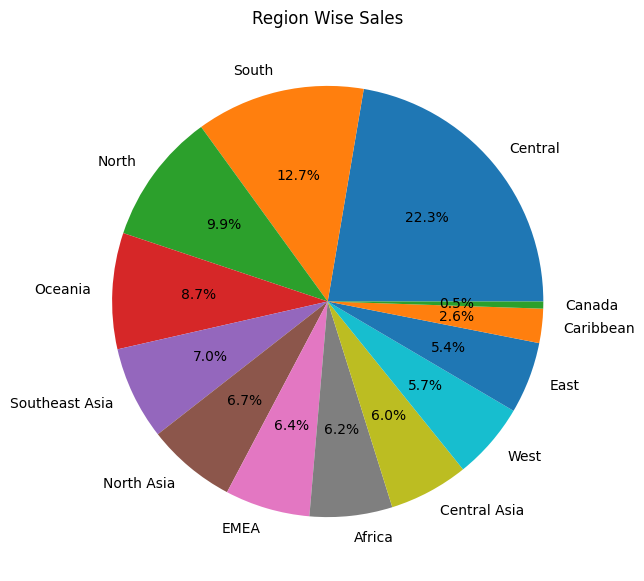

In [38]:
region_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Region Wise Sales")
plt.ylabel("")
plt.show()

In [39]:
country_sales = (
    df.groupby('country')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

country
United States     2297354.0
Australia          925257.0
France             858930.0
China              700591.0
Germany            628857.0
Mexico             622620.0
India              589664.0
United Kingdom     528570.0
Indonesia          404887.0
Brazil             361098.0
Name: sales, dtype: float64

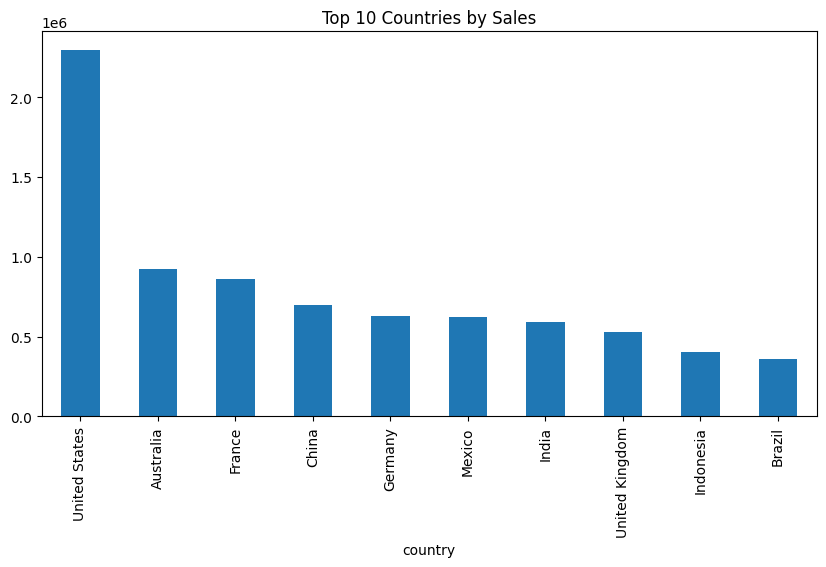

In [40]:
country_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Countries by Sales")
plt.show()

In [43]:
segment_sales = (
    df.groupby('segment')['sales']
      .sum()
      .sort_values(ascending=False)
)

segment_sales

segment
Consumer       6508141.0
Corporate      3824808.0
Home Office    2309956.0
Name: sales, dtype: float64

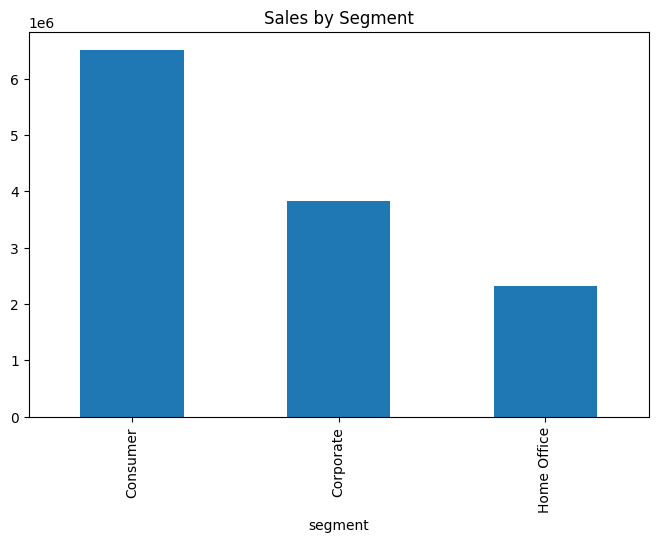

In [44]:
segment_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Segment")
plt.show()

In [45]:
priority_orders = (
    df['order_priority']
    .value_counts()
)

priority_orders

order_priority
Medium      29433
High        15501
Critical     3932
Low          2424
Name: count, dtype: int64

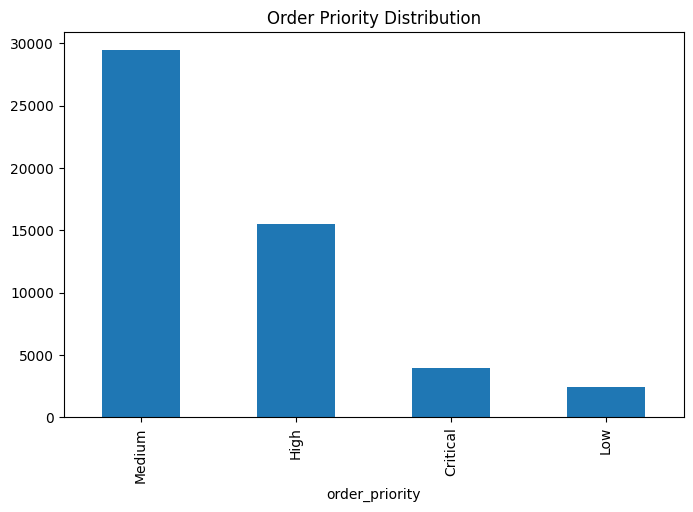

In [46]:
priority_orders.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Order Priority Distribution")
plt.show()

In [47]:
discount_profit = (
    df.groupby('discount')['profit']
      .mean()
)

discount_profit

discount
0.000      61.039514
0.002     125.762649
0.070     140.990022
0.100      64.071216
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.202     -14.518847
0.250       4.043371
0.270      -4.317213
0.300     -57.899557
0.320     -88.560656
0.350    -116.144693
0.370     -78.462191
0.400     -45.246603
0.402    -109.908138
0.450     -41.610973
0.470     -42.982420
0.500     -97.140158
0.550    -315.067200
0.570    -526.129000
0.600     -81.732147
0.602    -213.279085
0.650    -365.997971
0.700    -104.339576
0.800    -122.203244
0.850   -1534.329000
Name: profit, dtype: float64

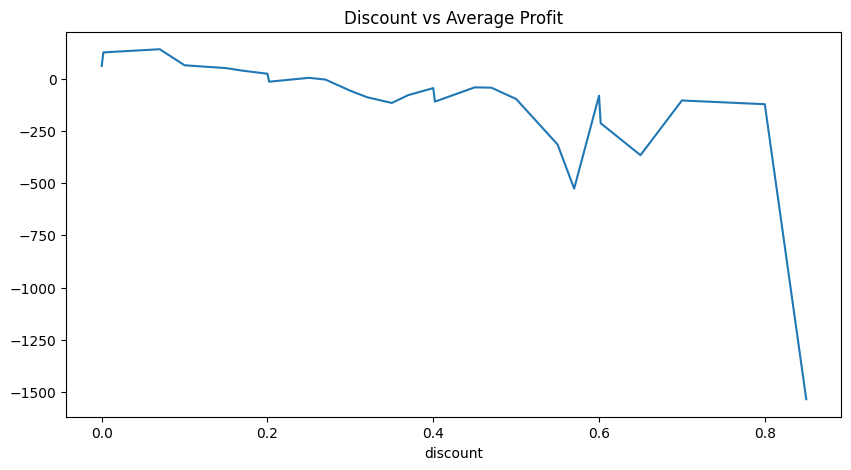

In [48]:
discount_profit.plot(
    figsize=(10,5)
)

plt.title("Discount vs Average Profit")
plt.show()
